In [47]:
import pandas as pd
import matplotlib.pyplot as plt
pd.options.display.max_columns = None  # Show all columns in the output

In [48]:
stops = pd.read_excel(r'C:\Users\ali.etezady\OneDrive - Resource Systems Group, Inc\SANDAG\SANDAG Tour Survey_FINAL.xlsx', 
                     sheet_name='Trips')

persons = pd.read_excel(r'C:\Users\ali.etezady\OneDrive - Resource Systems Group, Inc\SANDAG\SANDAG Tour Survey_FINAL.xlsx', 
                     sheet_name='Person')

dict = pd.read_excel(r'C:\Users\ali.etezady\OneDrive - Resource Systems Group, Inc\SANDAG\SANDAG Tour Survey_FINAL.xlsx', 
                     sheet_name='Data Dictionary')

## functions

In [ ]:
def create_trips_from_stops(data):
    """
    Convert stops data to trips data.
    Group by 'token' (trip chain identifier) and sort by 'trip_number' (stop sequence).
    Each trip connects two consecutive stops in the same trip chain.
    """

    # data['trip_number'] = data.groupby('token').cumcount() + 1
    trips_list = []
    
    # Group by token (person_id) and process each trip chain
    for token, trip_chain in data.groupby('token'):
        # Sort stops by trip_number to ensure correct order
        trip_chain = trip_chain.sort_values('trip_number').reset_index(drop=True)
        
        # Skip if trip chain has less than 2 stops (can't form a trip)
        if len(trip_chain) < 2:
            continue
            
        # Create trips from consecutive stops
        for i in range(len(trip_chain) - 1):
            origin_stop = trip_chain.iloc[i]
            destination_stop = trip_chain.iloc[i + 1]
            
            # Create trip record
            trip = {
                'PER_ID':                        token,  # Person ID (using token as person identifier)
                'HH_ID':                         'HH_' + token,      # Household ID (dummy value)
                'DAY_ID':                        1,                   # Day ID (dummy value)
                'PER_NUM':                       1,                   # Person number (dummy value)
                'DAYNUM':                        1,                   # Day number (dummy value)
                'trip_id':                       destination_stop['id'],  # Trip ID (renamed from original 'id' column)
                'trip_number':                   i + 1,  # Trip number in the chain (1, 2, 3, ...)
                'orig_purpose':                  origin_stop['purpose_at_stop'],
                'orig_purpose_at_stop_other':    origin_stop['purpose_at_stop_other'],
                'dest_purpose':                  destination_stop['purpose_at_stop'],
                'dest_purpose_at_stop_other':    destination_stop['purpose_at_stop_other'],
                'travel_mode1':                  destination_stop['travel_mode1'],  # Primary mode used to reach destination
                'travel_mode2':                  destination_stop['travel_mode2'],
                'travel_mode3':                  destination_stop['travel_mode3'],
                'travel_mode4':                  destination_stop['travel_mode4'],
                'travel_mode5':                  destination_stop['travel_mode5'],
                'accessmode':                    destination_stop['accessmode'],
                'egressmode':                    destination_stop['egressmode'],
                'depart_time':                   origin_stop['depart_time'],
                'arrive_time':                   destination_stop['arrive_time'],
                'o_lon':                         origin_stop['stop_longitude'],
                'o_lat':                         origin_stop['stop_latitude'],
                'd_lon':                         destination_stop['stop_longitude'],
                'd_lat':                         destination_stop['stop_latitude'],
                'day_id':                        1

            }
            
            trips_list.append(trip)


    # Convert to DataFrame
    trips_df = pd.DataFrame(trips_list)

    # recode change mode purpose to code 16
    trips_df['orig_purpose'] = trips_df['orig_purpose'].replace({'change mode': '16'})
    trips_df['dest_purpose'] = trips_df['dest_purpose'].replace({'change mode': '16'})
    trips_df['orig_purpose'] = trips_df['orig_purpose'].replace({'-oth-': '17'})
    trips_df['dest_purpose'] = trips_df['dest_purpose'].replace({'-oth-': '17'})

    #replace 
    
    return trips_df

def get_mode_combination(row):
    modes = []
    for i in range(1, 6):
        mode = row[f'travel_mode{i}']
        if pd.notna(mode):
            modes.append(mode)
    return ' + '.join(modes) if modes else 'No Mode'

def print_mode_combination_share(mode_combinations, top_n=15):
    """Prints the top N mode combinations and their share of total trips."""
    total_trips = mode_combinations.sum()
    print(f"Total unique combinations: {len(mode_combinations)}")
    print(f"\nTop {top_n} most frequent combinations:")
    print(mode_combinations.head(top_n))
    print("\n=== DETAILED COMBINATION BREAKDOWN ===")
    print("Showing combinations with their component modes and share:")
    for combo, count in mode_combinations.head(top_n).items():
        share = (count / total_trips) * 100
        print(f"{combo}: {count} trips ({share:.1f}% share)")

def construct_nontransit_trip_mode(row, mode_hierarchy):
    """
    Determine the representative mode based on hierarchy.
    Returns the mode with highest priority from the combination.
    """
    modes_in_trip = []
    for i in range(1, 6):
        mode = row[f'travel_mode{i}']
        if pd.notna(mode):
            modes_in_trip.append(mode)
    
    if not modes_in_trip:
        return 'No Mode'
    
    # Find mode with highest priority
    max_priority = 0
    representative_mode = modes_in_trip[0]
    
    for mode in modes_in_trip:
        priority = mode_hierarchy.get(mode, 0)
        if priority > max_priority:
            max_priority = priority
            representative_mode = mode
    
    return representative_mode

def construct_transit_trip_mode(row, accessegress_def):
    # Access/Egress logic
    access = row['accessmode']
    egress = row['egressmode']
    access_type = None
    egress_type = None
    
    # Helper to map mode to type
    def get_accessegress_type(mode):
        for k, v in accessegress_def.items():
            if mode in v:
                return k
        return None
    
    access_type = get_accessegress_type(access)
    egress_type = get_accessegress_type(egress)
    
    # Determine access/egress part
    if access_type == 'WALK' and egress_type == 'WALK':
        ae_part = 'WALK'
    elif access_type in ['PNR', 'KNR', 'TNC'] or egress_type in ['PNR', 'KNR', 'TNC']:
        # Priority: PNR > KNR > TNC
        for t in ['PNR', 'KNR', 'TNC']:
            if access_type == t or egress_type == t:
                ae_part = t
                break
    else:
        ae_part = 'OTHER'
    
    # Transit segment logic
    combo = row['mode_combination']
    has_SQ010 = 'SQ010' in combo
    has_SQ011 = 'SQ011' in combo
    if has_SQ010 and not has_SQ011:
        transit_part = 'LOC'
    elif has_SQ011 and not has_SQ010:
        transit_part = 'PRM'
    elif has_SQ010 and has_SQ011:
        transit_part = 'MIX'
    else:
        transit_part = 'NONE'
    
    return f"{ae_part}_{transit_part}"

def create_hh_df(persons):
    """
    Create a dummy household (HH) DataFrame from the persons DataFrame.
    Each unique person is assigned to a household.
    """

    dummy_HH = pd.DataFrame()
    dummy_HH['HH_ID'] = persons[['token']].drop_duplicates()
    
    return dummy_HH

def create_person_df(original_persons):
    """
    Create a person DataFrame from the persons DataFrame.
    Each unique person is assigned a unique ID.
    """
    persons_df = pd.DataFrame()
    persons_df['HH_ID'] = 'HH_' + original_persons['token']
    persons_df['PER_ID'] = original_persons['token']
    persons_df['age'] = original_persons['age']
    persons_df['student'] = original_persons['student']
    persons_df['employment'] = original_persons['employment']
    persons_df['school_type'] = original_persons['school_type']


    return persons_df



## process stops

### make trips

In [79]:
trips_df = create_trips_from_stops(stops)


In [81]:
# Display basic information
print(f"Original stops data: {len(stops)} records")
print(f"Created trips data: {len(trips_df)} trips")
print(f"Number of unique trip IDs: {trips_df['trip_id'].nunique()}")
print('--------------------------------------------')
print(f"Original number of unique people: {persons['token'].nunique()}")
print(f"Number of unique people in the processed trips: {trips_df['PER_ID'].nunique()}")
missing = persons[~persons['token'].isin(trips_df['PER_ID'])].token.to_list()
stops[stops['token'].isin(missing)].did_travel.value_counts()
print(f'Appears {len(missing)} people did not travel')


Original stops data: 3311 records
Created trips data: 2285 trips
Number of unique trip IDs: 2285
--------------------------------------------
Original number of unique people: 1026
Number of unique people in the processed trips: 920
Appears 106 people did not travel


### create modes

#### transit trips

Transit trips have values for access and egress mode columns. This has been confirmed by exploring the data. No trip without access/egress values have SQ010 or SQ011 as travel_modes

In [52]:
transit_trips = trips_df[~(trips_df['accessmode'].isna() | trips_df['egressmode'].isna())]
# Add mode combination column for analysis
transit_trips['mode_combination'] = transit_trips.apply(get_mode_combination, axis=1)
# Count frequency of each combination
transit_mode_combinations = transit_trips['mode_combination'].value_counts()
print_mode_combination_share(transit_mode_combinations, top_n=50)

Total unique combinations: 186

Top 50 most frequent combinations:
SQ010                                    206
SQ011                                    111
SQ001 + SQ010                             86
SQ001 + SQ010 + SQ001                     74
SQ010 + SQ001                             53
SQ010 + SQ010                             41
SQ001 + SQ011                             40
SQ001 + SQ010 + SQ010                     30
SQ001 + SQ011 + SQ001                     25
SQ001 + SQ010 + SQ011                     25
SQ011 + SQ001                             24
SQ001 + SQ010 + SQ010 + SQ001             18
SQ010 + SQ011                             16
SQ001 + SQ010 + SQ011 + SQ001             16
SQ001 + SQ011 + SQ010                     15
SQ011 + SQ010                             15
SQ010 + SQ010 + SQ001                     14
SQ010 + SQ011 + SQ010                     12
SQ001 + SQ011 + SQ010 + SQ001             11
SQ001 + SQ010 + SQ010 + SQ010             11
SQ011 + SQ010 + SQ001            

C:\Users\ali.etezady\AppData\Local\Temp\ipykernel_32588\2727587586.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transit_trips['mode_combination'] = transit_trips.apply(get_mode_combination, axis=1)


In [53]:
transit_trips[transit_trips['mode_combination']=='SQ010 + SQ008']

,PER_ID,HH_ID,DAY_ID,PER_NUM,DAYNUM,trip_id,trip_number,orig_purpose,orig_purpose_at_stop_other,dest_purpose,dest_purpose_at_stop_other,travel_mode1,travel_mode2,travel_mode3,travel_mode4,travel_mode5,accessmode,egressmode,depart_time,arrive_time,o_lon,o_lat,d_lon,d_lat,day_id,mode_combination
712,IRYVS,HH_IRYVS,1,1,1,167,2,1,NaN,15,NaN,SQ010,SQ008,NaN,NaN,NaN,SQ001,SQ008,17:15:00,17:33:00,-117.160619,32.717267,-117.107137,32.897579,1,SQ010 + SQ008
958,LXNYU,HH_LXNYU,1,1,1,2689,1,NaN,NaN,9,NaN,SQ010,SQ008,NaN,NaN,NaN,SQ001,SQ001,07:00:00,07:08:00,-117.148241,32.706527,-117.103861,32.703415,1,SQ010 + SQ008
1820,VGDKS,HH_VGDKS,1,1,1,3951,3,3,NaN,7,NaN,SQ010,SQ008,NaN,NaN,NaN,SQ001,SQ001,18:37:11,19:27:52,-117.152602,32.716735,-117.146449,32.913118,1,SQ010 + SQ008
2153,ZBKJX,HH_ZBKJX,1,1,1,5576,2,1,NaN,15,NaN,SQ010,SQ008,NaN,NaN,NaN,SQ007,SQ001,18:30:00,18:51:00,-117.169026,32.720076,-117.113308,32.573582,1,SQ010 + SQ008


In [54]:
accessegress_def = {'WALK': ['SQ001', 'SQ002', 'SQ003', 'SQ004', 'SQ005', 'SQ006', 'SQ015', 'SQ016'], # walk, wheelchair, skateboard, (e-)bike, e-scooter
                    'PNR': ['SQ008', 'SQ009'], # Drove alone and parked, Drove or rode with others and parked
                    'KNR': ['SQ007'], # Dropped off by someone else,
                    'TNC': ['SQ012', 'SQ013', 'SQ014', 'SQ017', 'SQ018'] # Taxi, TNC, Shuttle
}

C:\Users\ali.etezady\AppData\Local\Temp\ipykernel_32588\2312177146.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transit_trips['trip_mode'] = transit_trips.apply(lambda row: construct_transit_trip_mode(row, accessegress_def), axis=1)


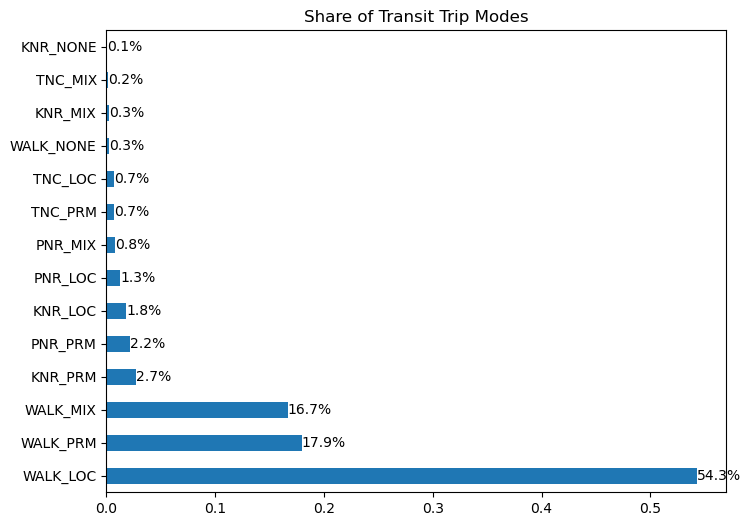

In [55]:
# Apply to transit_trips
transit_trips['trip_mode'] = transit_trips.apply(lambda row: construct_transit_trip_mode(row, accessegress_def), axis=1)
#add shares to the top of the bars, make horizontal bars
ax = transit_trips.trip_mode.value_counts(normalize=True).plot(kind='barh', figsize=(8, 6), title='Share of Transit Trip Modes')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1%}', (p.get_width(), p.get_y() + p.get_height() / 2), ha='left', va='center')

#### non-transit trips

In [56]:
_mode_hierarchy = {

    'Drove alone and parked': 7,
    'Drove or rode with others and parked': 7,
    'Was dropped off by someone I know': 6,

    'Taxi': 5, 
    'Uber, Lyft, etc ( Private)': 5,
    'Uber, lyft, (Pol and Shared)': 5,
    'Electric vehicle shuttle': 5,
    'other shuttle': 5,
    
    # Active transport - motorized (medium priority)
    'E-Bike (Personal)': 4,
    'E-Bike (Shared)': 4,
    'E-scooter (Personal)': 3,
    'E-scooter (Shared)': 3,
    'Bike (Personal)': 3,
    
    # Active transport - non-motorized (lower priority - often access/egress)
    'Skateboard': 2,
    'Wheelchair': 2,
    'Walk': 1  # Lowest priority - often just access/egress to main mode
}

mode_dict = dict[dict.Column=='travel_mode'][['Code', 'Value']].set_index('Code')['Value'].to_dict()
mode_hierarchy = {k: _mode_hierarchy[v] for k, v in mode_dict.items() if v in _mode_hierarchy}

In [57]:
nonTransit_trips = trips_df[(trips_df['accessmode'].isna() | trips_df['egressmode'].isna())]
# Add mode combination column for analysis
nonTransit_trips['mode_combination'] = nonTransit_trips.apply(get_mode_combination, axis=1)
nontransit_mode_combinations = nonTransit_trips['mode_combination'].value_counts()
print_mode_combination_share(nontransit_mode_combinations, top_n=15)

Total unique combinations: 53

Top 15 most frequent combinations:
SQ001            645
SQ008            131
SQ007            101
SQ009             93
SQ012             60
SQ004             26
SQ016             14
SQ003             13
SQ002              8
SQ001 + SQ007      7
SQ014              7
SQ006              7
SQ001 + SQ012      6
SQ011              4
SQ007 + SQ001      4
Name: mode_combination, dtype: int64

=== DETAILED COMBINATION BREAKDOWN ===
Showing combinations with their component modes and share:
SQ001: 645 trips (54.3% share)
SQ008: 131 trips (11.0% share)
SQ007: 101 trips (8.5% share)
SQ009: 93 trips (7.8% share)
SQ012: 60 trips (5.1% share)
SQ004: 26 trips (2.2% share)
SQ016: 14 trips (1.2% share)
SQ003: 13 trips (1.1% share)
SQ002: 8 trips (0.7% share)
SQ001 + SQ007: 7 trips (0.6% share)
SQ014: 7 trips (0.6% share)
SQ006: 7 trips (0.6% share)
SQ001 + SQ012: 6 trips (0.5% share)
SQ011: 4 trips (0.3% share)
SQ007 + SQ001: 4 trips (0.3% share)


C:\Users\ali.etezady\AppData\Local\Temp\ipykernel_32588\2933730775.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonTransit_trips['mode_combination'] = nonTransit_trips.apply(get_mode_combination, axis=1)


C:\Users\ali.etezady\AppData\Local\Temp\ipykernel_32588\2410654777.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonTransit_trips['trip_mode'] = nonTransit_trips.apply(construct_nontransit_trip_mode, axis=1, args=(mode_hierarchy,))
C:\Users\ali.etezady\AppData\Local\Temp\ipykernel_32588\2410654777.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonTransit_trips['trip_mode'] = nonTransit_trips['trip_mode'].map(mode_dict)


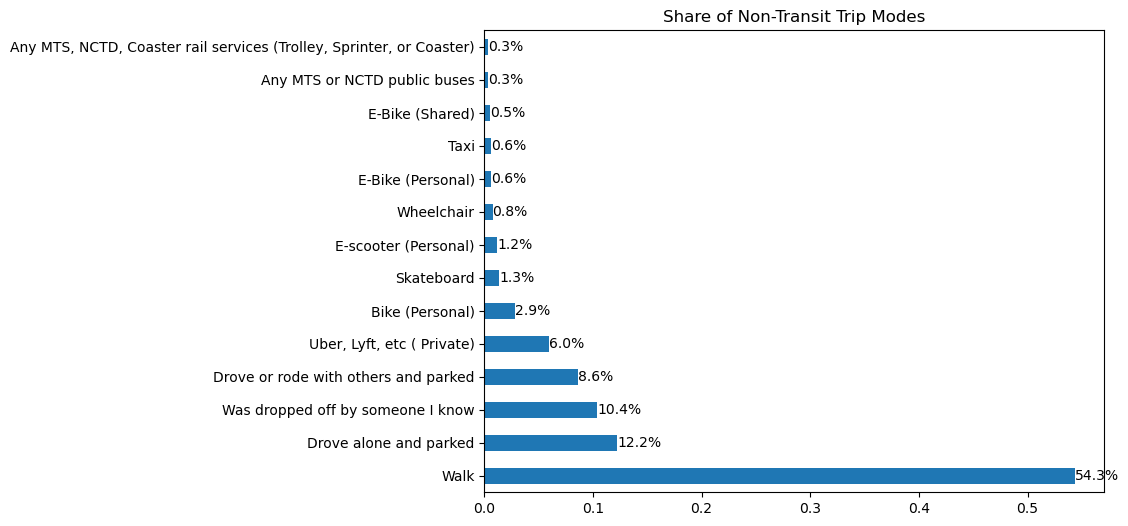

In [58]:
nonTransit_trips['trip_mode'] = nonTransit_trips.apply(construct_nontransit_trip_mode, axis=1, args=(mode_hierarchy,))
nonTransit_trips['trip_mode'] = nonTransit_trips['trip_mode'].map(mode_dict)
ax = nonTransit_trips.trip_mode.value_counts(normalize=True).plot(kind='barh', figsize=(8, 6), title='Share of Non-Transit Trip Modes')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1%}', (p.get_width(), p.get_y() + p.get_height() / 2), ha='left', va='center')

#### join transit and non-transit data

In [59]:
trips_data_final = pd.concat([transit_trips, nonTransit_trips], axis=0)
assert len(trips_data_final) == len(trips_df)
print(f'Count of of transit trips: {len(transit_trips)}')
print(f'Count of of non-transit trips: {len(nonTransit_trips)}')
print(f'Total trips: {len(trips_data_final)}')
print(f'Share of transit trips: {len(transit_trips) / len(trips_data_final):.1%}')
print(f'Share of non-transit trips: {len(nonTransit_trips) / len(trips_data_final):.1%}')

Count of of transit trips: 1098
Count of of non-transit trips: 1187
Total trips: 2285
Share of transit trips: 48.1%
Share of non-transit trips: 51.9%


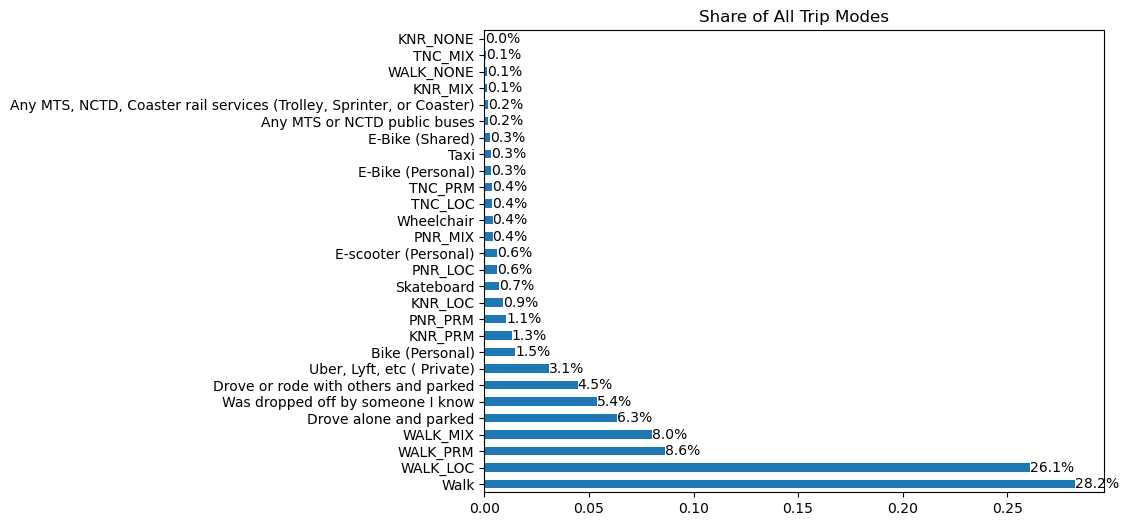

In [60]:
ax = trips_data_final.trip_mode.value_counts(normalize=True).plot(kind='barh', figsize=(8, 6), title='Share of All Trip Modes')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1%}', (p.get_width(), p.get_y() + p.get_height() / 2), ha='left', va='center')

In [61]:
trips_data_final[(trips_data_final.dest_purpose_at_stop_other.notna())&(~trips_data_final.trip_mode.str.contains('_'))][['trip_mode', 'dest_purpose_at_stop_other']].head(20)

,trip_mode,dest_purpose_at_stop_other
7,E-Bike (Personal),Coaster station
50,Was dropped off by someone I know,Bus to work
67,Walk,Getting to trolley
89,Walk,Waiting on bus 20
99,Walk,Change mode of transportation
102,Walk,Change mode
103,Walk,Change mode
146,Any MTS or NCTD public buses,trolley to bus
147,Walk,change buses
155,Any MTS or NCTD public buses,change buses


In [62]:
# Export
trips_data_final.to_csv('trips_final_revised.csv', index=False)

## create hh and person files

In [ ]:
hh_df = create_hh_df(persons)
persons_df = create_person_df(persons)

# Export DataFrames
hh_df.to_csv('hh_df.csv', index=False)
persons_df.to_csv('persons_df.csv', index=False)
